In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [2]:
X_scaled = pd.read_csv('data/X_scaled.csv')
X_pca_2d = pd.read_csv('data/X_pca_2d.csv')
X_pca_3d = pd.read_csv('data/X_pca_3d.csv')
exam_scores = pd.read_csv('data/exam_scores.csv').squeeze()

print(f"X_scaled shape: {X_scaled.shape}")
print(f"X_pca_2d shape: {X_pca_2d.shape}")
print("Data loaded")

X_scaled shape: (6607, 21)
X_pca_2d shape: (6607, 2)
Data loaded


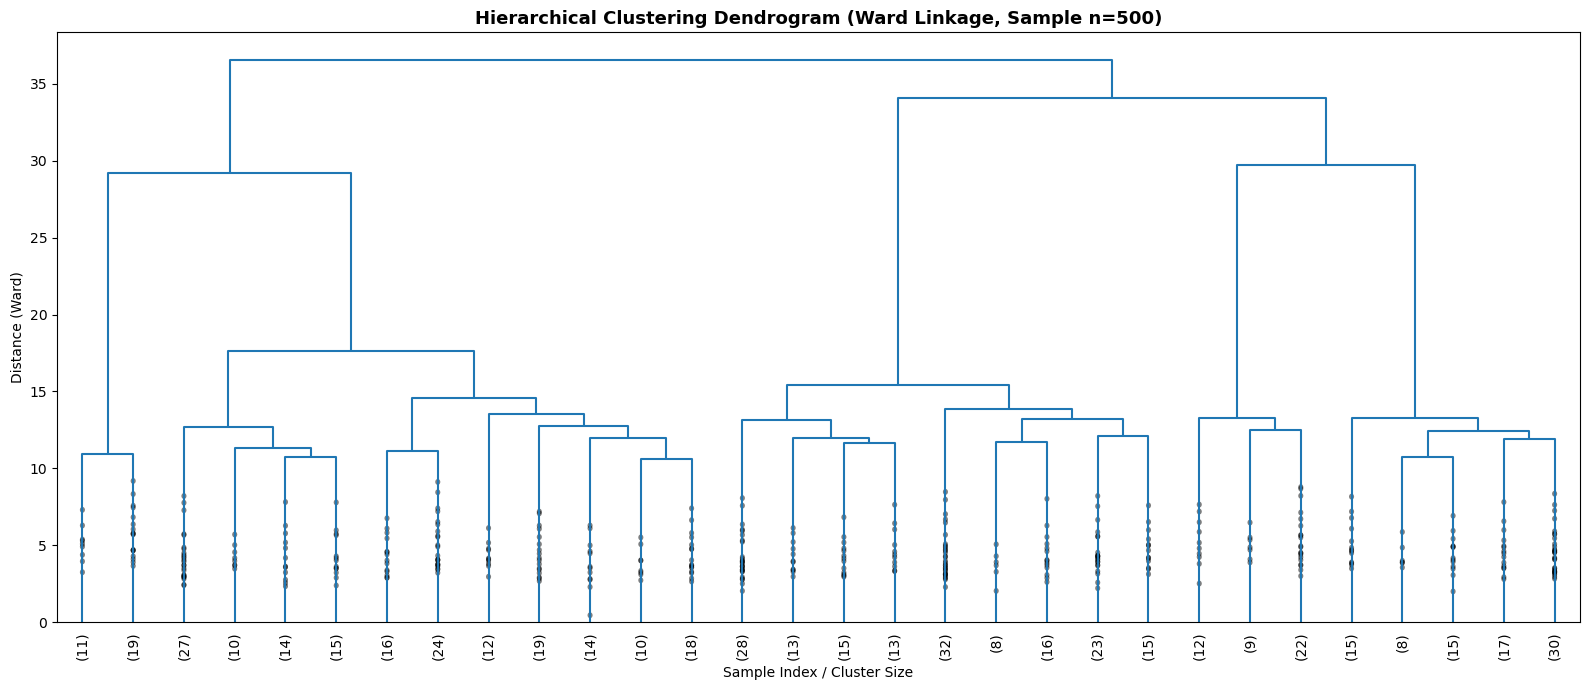

In [3]:
# Ward minimises within-cluster variance , so best default for this type of data
# Using a sample 500 rows for dendrogram readability bc full 6607 rows is unreadable

np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=500, replace=False)
X_sample = X_scaled.iloc[sample_idx].values

linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 7))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',   # show only last p merged clusters
    p=30,                    # show last 30 merges
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=0        # will be set manually after looking at the plot
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, Sample n=500)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Sample Index / Cluster Size')
plt.ylabel('Distance (Ward)')
plt.tight_layout()
plt.savefig('plots/hierarchical_dendrogram_full.png', dpi=150, bbox_inches='tight')
plt.show()

k=2 | Silhouette: 0.0539 | Davies-Bouldin: 3.5587 | Calinski-Harabasz: 427.5
k=3 | Silhouette: 0.0705 | Davies-Bouldin: 3.3971 | Calinski-Harabasz: 424.7
k=4 | Silhouette: 0.0903 | Davies-Bouldin: 2.8472 | Calinski-Harabasz: 426.8
k=5 | Silhouette: 0.1089 | Davies-Bouldin: 2.4731 | Calinski-Harabasz: 434.0
k=6 | Silhouette: 0.0831 | Davies-Bouldin: 2.9214 | Calinski-Harabasz: 370.3
k=7 | Silhouette: 0.0654 | Davies-Bouldin: 3.2245 | Calinski-Harabasz: 327.9
k=8 | Silhouette: 0.0683 | Davies-Bouldin: 3.3313 | Calinski-Harabasz: 293.0


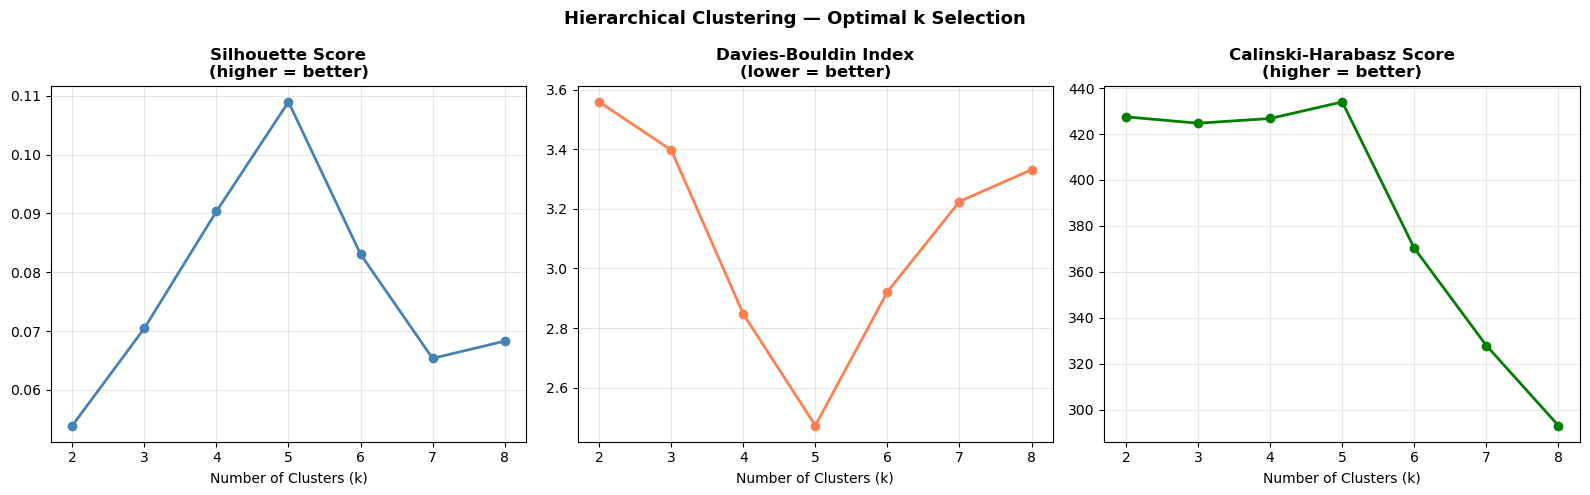

In [4]:
# Test k from 2 to 8

k_range = range(2, 9)
silhouette_scores = []
db_scores = []
ch_scores = []

for k in k_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels, sample_size=2000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    
    silhouette_scores.append(sil)
    db_scores.append(db)
    ch_scores.append(ch)
    
    print(f"k={k} | Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f} | Calinski-Harabasz: {ch:.1f}")

# Plot all three metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(k_range, silhouette_scores, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Silhouette Score\n(higher = better)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')

axes[1].plot(k_range, db_scores, marker='o', color='coral', linewidth=2)
axes[1].set_title('Davies-Bouldin Index\n(lower = better)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')

axes[2].plot(k_range, ch_scores, marker='o', color='green', linewidth=2)
axes[2].set_title('Calinski-Harabasz Score\n(higher = better)', fontweight='bold')
axes[2].set_xlabel('Number of Clusters (k)')

for ax in axes:
    ax.set_xticks(list(k_range))
    ax.grid(alpha=0.3)

plt.suptitle('Hierarchical Clustering — Optimal k Selection', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/hierarchical_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
OPTIMAL_K = 5 

model_final = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
cluster_labels = model_final.fit_predict(X_scaled)

results_df = X_scaled.copy()
results_df['Cluster'] = cluster_labels
results_df['Exam_Score'] = exam_scores.values
results_df['PC1'] = X_pca_2d['PC1'].values
results_df['PC2'] = X_pca_2d['PC2'].values

print(f"Final model fitted with k={OPTIMAL_K} ✓")
print(f"\nCluster distribution:")
print(results_df['Cluster'].value_counts().sort_index())

Final model fitted with k=5 ✓

Cluster distribution:
0    2149
1    2184
2     640
3     499
4    1135
Name: Cluster, dtype: int64


In [6]:
sil_final  = silhouette_score(X_scaled, cluster_labels, sample_size=2000, random_state=42)
db_final   = davies_bouldin_score(X_scaled, cluster_labels)
ch_final   = calinski_harabasz_score(X_scaled, cluster_labels)

print("FINAL MODEL EVALUATION")
print(f"Number of clusters:       {OPTIMAL_K}")
print(f"Silhouette Score:         {sil_final:.4f}  (higher is better, range -1 to 1)")
print(f"Davies-Bouldin Index:     {db_final:.4f}  (lower is better)")
print(f"Calinski-Harabasz Score:  {ch_final:.1f}  (higher is better)")

# Save metrics for comparison notebook
metrics = {
    'Model': 'Agglomerative Hierarchical',
    'Linkage': 'Ward',
    'n_clusters': OPTIMAL_K,
    'Silhouette Score': round(sil_final, 4),
    'Davies-Bouldin Index': round(db_final, 4),
    'Calinski-Harabasz Score': round(ch_final, 1)
}
pd.DataFrame([metrics]).to_csv('data/metrics_hierarchical.csv', index=False)
print("\nMetrics saved to data/metrics_hierarchical.csv")

FINAL MODEL EVALUATION
Number of clusters:       5
Silhouette Score:         0.1089  (higher is better, range -1 to 1)
Davies-Bouldin Index:     2.4731  (lower is better)
Calinski-Harabasz Score:  434.0  (higher is better)

Metrics saved to data/metrics_hierarchical.csv


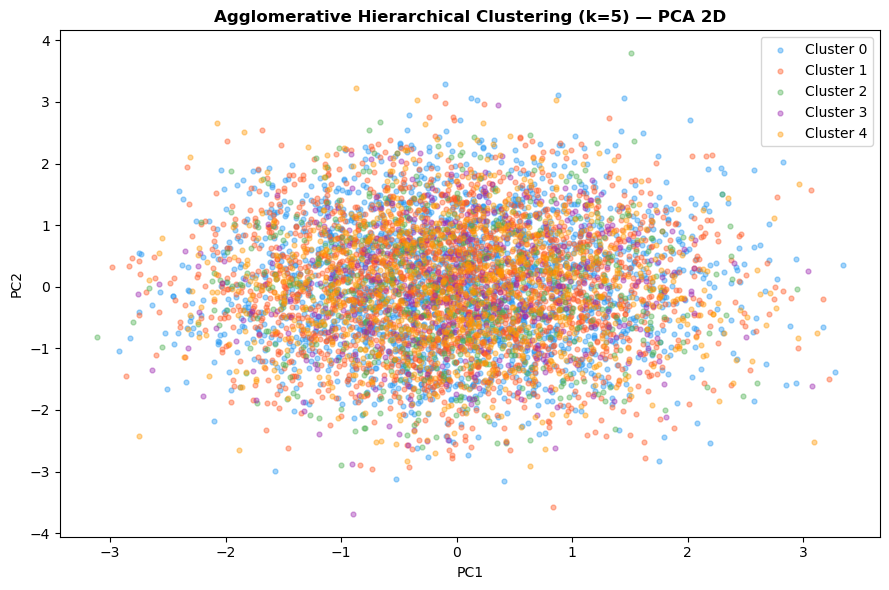

In [7]:
palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

plt.figure(figsize=(9, 6))
for cluster_id in sorted(results_df['Cluster'].unique()):
    mask = results_df['Cluster'] == cluster_id
    plt.scatter(
        results_df.loc[mask, 'PC1'],
        results_df.loc[mask, 'PC2'],
        label=f'Cluster {cluster_id}',
        alpha=0.4, s=12,
        color=palette[cluster_id]
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Agglomerative Hierarchical Clustering (k={OPTIMAL_K}) — PCA 2D', 
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plots/hierarchical_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

=== CLUSTER PROFILES ===
Cluster                    0      1      2      3      4
Hours_Studied          20.02  20.13  19.75  19.87  19.77
Attendance             80.34  79.84  79.05  80.72  79.77
Previous_Scores        75.25  74.83  75.42  74.85  75.08
Exam_Score             67.36  67.83  66.32  66.54  66.68
Tutoring_Sessions       1.50   1.47   1.52   1.54   1.50
Sleep_Hours             7.03   7.02   7.11   6.97   7.01
Physical_Activity       2.96   2.95   3.00   3.01   2.98
Motivation_Level        0.92   0.91   0.90   0.86   0.90
Access_to_Resources     1.09   1.10   1.09   1.13   1.10
Parental_Involvement    1.09   1.10   1.10   1.06   1.06
Family_Income           0.78   0.80   0.82   0.78   0.77
Learning_Disabilities   0.00   0.00   1.00   0.10   0.00


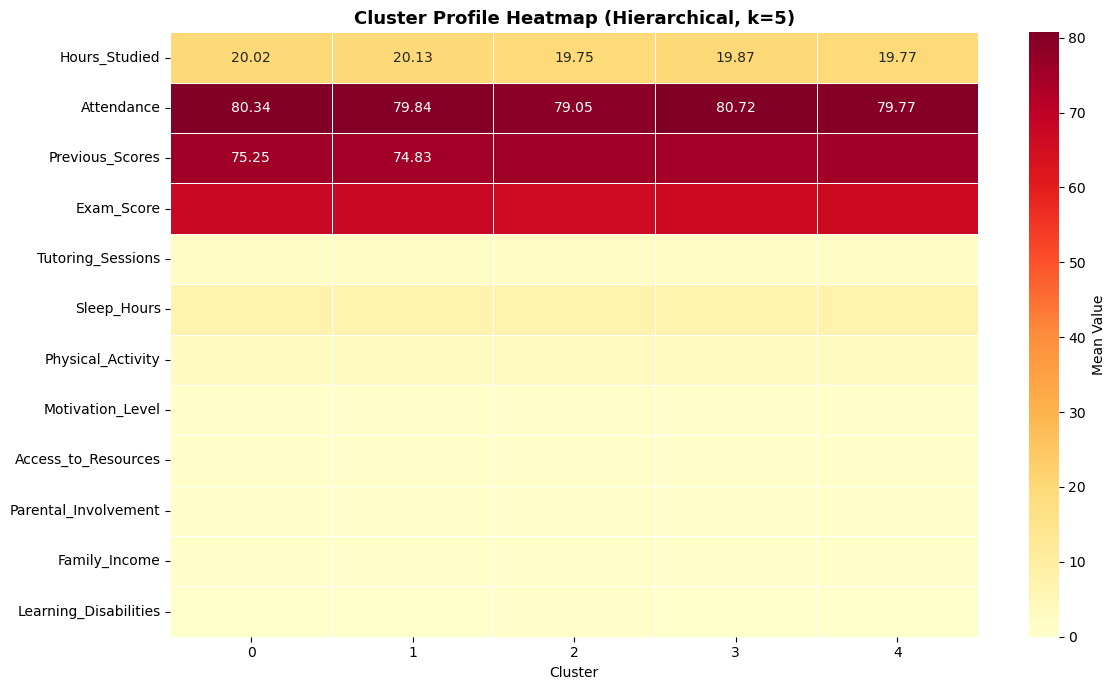

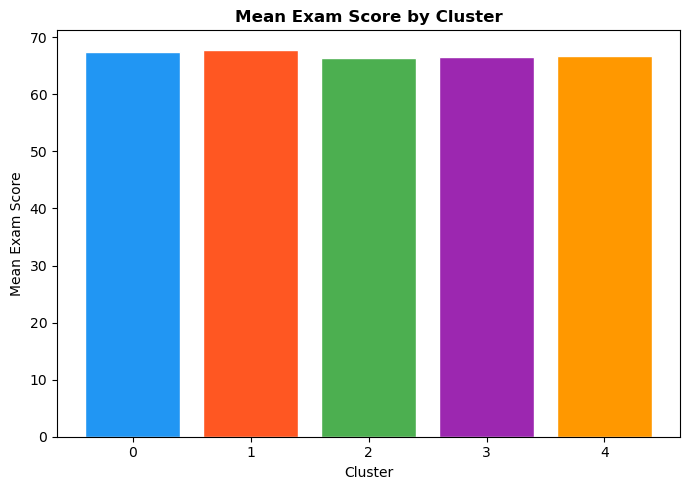

In [8]:
df_encoded = pd.read_csv('data/student_preprocessed.csv')
df_encoded['Cluster'] = cluster_labels

# Profile: mean of key features per cluster
profile_cols = [
    'Hours_Studied', 'Attendance', 'Previous_Scores', 'Exam_Score',
    'Tutoring_Sessions', 'Sleep_Hours', 'Physical_Activity',
    'Motivation_Level', 'Access_to_Resources', 'Parental_Involvement',
    'Family_Income', 'Learning_Disabilities'
]

profile = df_encoded.groupby('Cluster')[profile_cols].mean().round(2)
print("=== CLUSTER PROFILES ===")
print(profile.T)  # transposed for readability

# Heatmap of cluster profiles
plt.figure(figsize=(12, 7))
sns.heatmap(profile.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Mean Value'})
plt.title(f'Cluster Profile Heatmap (Hierarchical, k={OPTIMAL_K})', 
          fontweight='bold', fontsize=13)
plt.xlabel('Cluster')
plt.tight_layout()
plt.savefig('plots/hierarchical_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart comparing Exam_Score across clusters
plt.figure(figsize=(7, 5))
exam_by_cluster = df_encoded.groupby('Cluster')['Exam_Score'].mean()
plt.bar(exam_by_cluster.index, exam_by_cluster.values, 
        color=[palette[i] for i in exam_by_cluster.index], edgecolor='white')
plt.xlabel('Cluster')
plt.ylabel('Mean Exam Score')
plt.title('Mean Exam Score by Cluster', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/hierarchical_exam_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Cluster labels based on profile analysis
cluster_names = {
    0: 'General Students A',
    1: 'General Students B',
    2: 'Students with Learning Disabilities',
    3: 'At-Risk Borderline Group',
    4: 'General Students C'
}

df_encoded['Cluster_Label'] = df_encoded['Cluster'].map(cluster_names)

print("Cluster label distribution:")
print(df_encoded['Cluster_Label'].value_counts())

# Show mean exam score per labelled cluster
print("\nMean Exam Score per Cluster:")
print(df_encoded.groupby('Cluster_Label')['Exam_Score'].mean().round(2).sort_values())

df_encoded.to_csv('data/hierarchical_labelled.csv', index=False)
print("\nLabelled dataset saved")

Cluster label distribution:
General Students B                     2184
General Students A                     2149
General Students C                     1135
Students with Learning Disabilities     640
At-Risk Borderline Group                499
Name: Cluster_Label, dtype: int64

Mean Exam Score per Cluster:
Cluster_Label
Students with Learning Disabilities    66.32
At-Risk Borderline Group               66.54
General Students C                     66.68
General Students A                     67.36
General Students B                     67.83
Name: Exam_Score, dtype: float64

Labelled dataset saved


In [10]:
linkage_methods = ['ward', 'complete', 'average', 'single']
results_linkage = []

X_array = np.array(X_scaled)

for method in linkage_methods:
    try:
        model = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage=method)
        labels = model.fit_predict(X_array)
        
        unique_clusters = len(np.unique(labels))
        print(f"'{method}': {unique_clusters} unique clusters formed")
        
        if unique_clusters < 2:
            raise ValueError(f"Only {unique_clusters} cluster formed")
        
        sil = silhouette_score(X_array, labels, sample_size=2000, random_state=42)
        db  = davies_bouldin_score(X_array, labels)
        
        results_linkage.append({
            'Linkage Method': method,
            'Silhouette Score': round(sil, 4),
            'Davies-Bouldin Index': round(db, 4),
            'Note': 'Valid'
        })
        print(f"  → Silhouette: {sil:.4f}, DB: {db:.4f}")
        
    except Exception as e:
        print(f"'{method}' failed: {e}")
        results_linkage.append({
            'Linkage Method': method,
            'Silhouette Score': 'N/A',
            'Davies-Bouldin Index': 'N/A',
            'Note': 'Degenerate — chaining effect, all points in 1 cluster'
        })

linkage_df = pd.DataFrame(results_linkage)
print("\n=== LINKAGE METHOD COMPARISON ===")
print(linkage_df.to_string(index=False))
linkage_df.to_csv('data/hierarchical_linkage_comparison.csv', index=False)

'ward': 5 unique clusters formed
  → Silhouette: 0.1089, DB: 2.4731
'complete': 5 unique clusters formed
  → Silhouette: 0.0594, DB: 3.1838
'average': 5 unique clusters formed
  → Silhouette: 0.1127, DB: 2.0189
'single': 5 unique clusters formed
'single' failed: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

=== LINKAGE METHOD COMPARISON ===
Linkage Method Silhouette Score Davies-Bouldin Index                                                  Note
          ward           0.1089               2.4731                                                 Valid
      complete           0.0594               3.1838                                                 Valid
       average           0.1127               2.0189                                                 Valid
        single              N/A                  N/A Degenerate — chaining effect, all points in 1 cluster


In [11]:
# check: average linkage k=3 vs ward k=5
model_avg_k3 = AgglomerativeClustering(n_clusters=3, linkage='average')
labels_avg_k3 = model_avg_k3.fit_predict(X_array)

print("Average linkage k=3 cluster distribution:")
print(pd.Series(labels_avg_k3).value_counts().sort_index())

Average linkage k=3 cluster distribution:
0      15
1    6589
2       3
dtype: int64


In [12]:
# check distribution
print("Cluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())
print(f"\nSmallest cluster: {pd.Series(cluster_labels).value_counts().min()} students")
print(f"Largest cluster:  {pd.Series(cluster_labels).value_counts().max()} students")
print(f"Imbalance ratio:  {pd.Series(cluster_labels).value_counts().max() / pd.Series(cluster_labels).value_counts().min():.1f}x")

Cluster distribution:
0    2149
1    2184
2     640
3     499
4    1135
dtype: int64

Smallest cluster: 499 students
Largest cluster:  2184 students
Imbalance ratio:  4.4x


In [13]:
df_encoded['Cluster'] = cluster_labels
print(df_encoded.groupby('Cluster')['Learning_Disabilities'].mean().round(3))
print(df_encoded.groupby('Cluster').size())

Cluster
0    0.001
1    0.002
2    0.998
3    0.098
4    0.000
Name: Learning_Disabilities, dtype: float64
Cluster
0    2149
1    2184
2     640
3     499
4    1135
dtype: int64


In [14]:
profile_k5 = df_encoded.groupby('Cluster_Label')[profile_cols].mean().round(2)
print(profile_k5.T)

Cluster_Label          At-Risk Borderline Group  General Students A  \
Hours_Studied                             19.87               20.02   
Attendance                                80.72               80.34   
Previous_Scores                           74.85               75.25   
Exam_Score                                66.54               67.36   
Tutoring_Sessions                          1.54                1.50   
Sleep_Hours                                6.97                7.03   
Physical_Activity                          3.01                2.96   
Motivation_Level                           0.86                0.92   
Access_to_Resources                        1.13                1.09   
Parental_Involvement                       1.06                1.09   
Family_Income                              0.78                0.78   
Learning_Disabilities                      0.10                0.00   

Cluster_Label          General Students B  General Students C  \
Hours_Studi

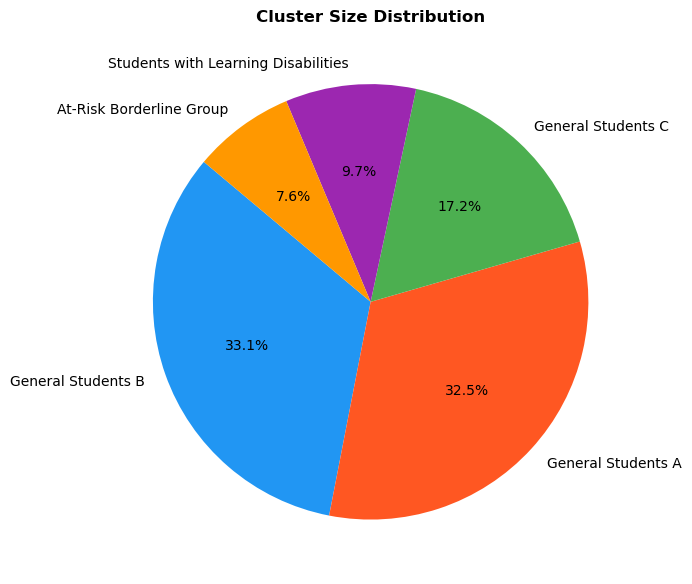

In [15]:
plt.figure(figsize=(7, 7))
sizes = df_encoded['Cluster_Label'].value_counts()
plt.pie(sizes.values, labels=sizes.index, autopct='%1.1f%%',
        colors=palette[:len(sizes)], startangle=140)
plt.title('Cluster Size Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/hierarchical_cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

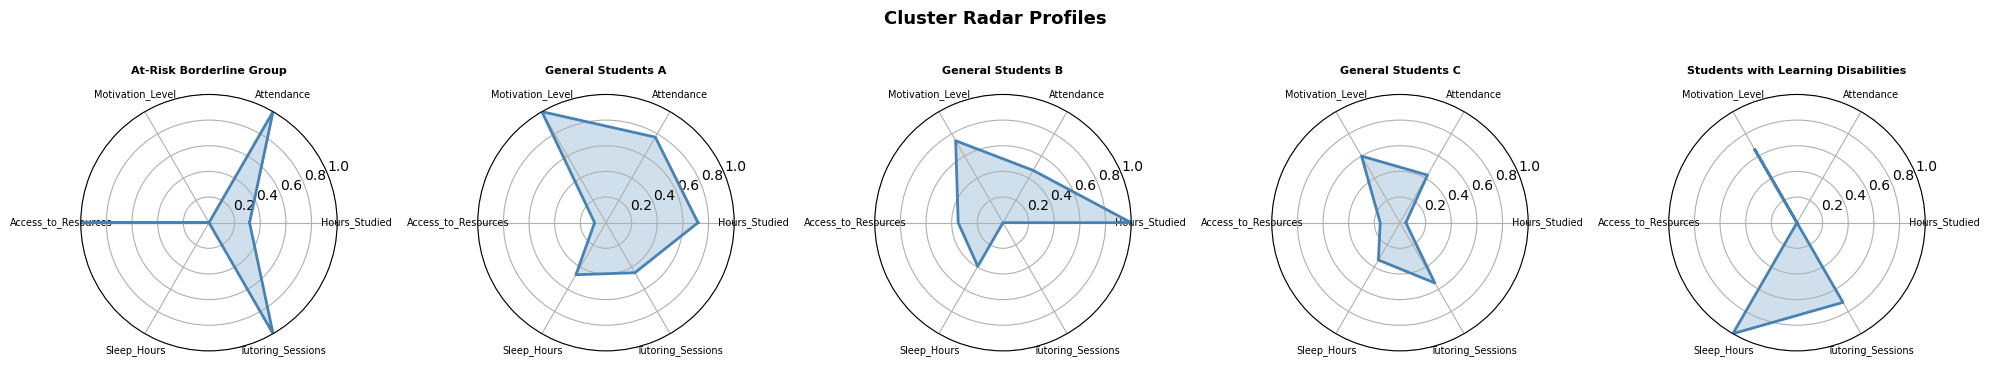

In [16]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalise profile for radar chart (0-1 scale)
radar_cols = ['Hours_Studied', 'Attendance', 'Motivation_Level', 
              'Access_to_Resources', 'Sleep_Hours', 'Tutoring_Sessions']

profile_radar = df_encoded.groupby('Cluster_Label')[radar_cols].mean()
profile_norm = (profile_radar - profile_radar.min()) / (profile_radar.max() - profile_radar.min())

angles = np.linspace(0, 2*np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]  # close the circle

fig, axes = plt.subplots(1, 5, figsize=(20, 4), subplot_kw=dict(polar=True))

for ax, (label, row) in zip(axes, profile_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, linewidth=2, color='steelblue')
    ax.fill(angles, values, alpha=0.25, color='steelblue')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_cols, size=7)
    ax.set_title(label, size=8, fontweight='bold', pad=15)
    ax.set_ylim(0, 1)

plt.suptitle('Cluster Radar Profiles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/hierarchical_radar.png', dpi=150, bbox_inches='tight')
plt.show()

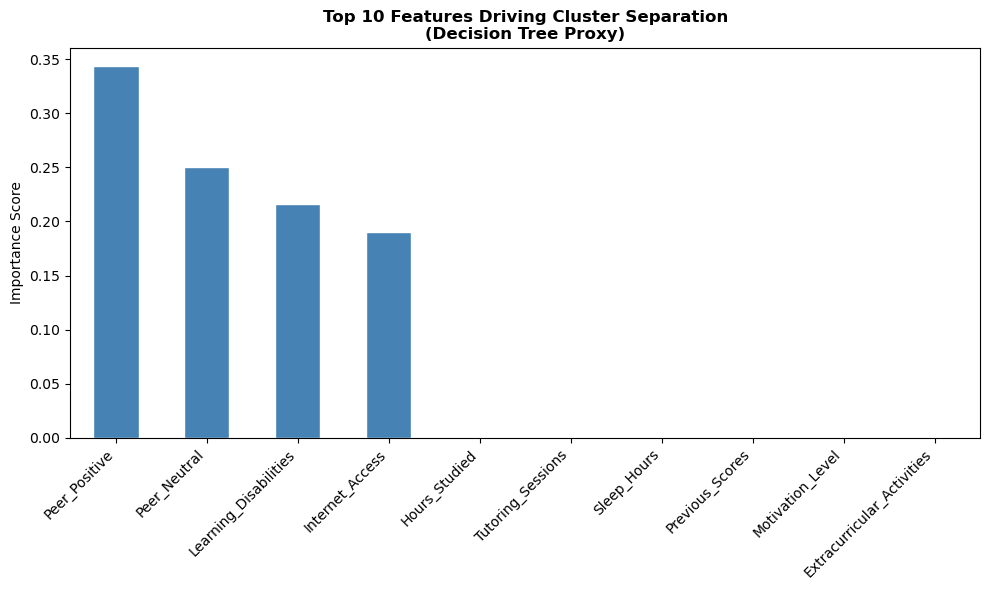

Top 5 most important features:
Peer_Positive            0.343538
Peer_Neutral             0.250539
Learning_Disabilities    0.215725
Internet_Access          0.189932
Hours_Studied            0.000136
dtype: float64
Feature importance saved


In [17]:
from sklearn.tree import DecisionTreeClassifier

# Decision tree to reveal which features the clustering relied on most
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_scaled, cluster_labels)
importances = pd.Series(dt.feature_importances_, 
                        index=X_scaled.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Features Driving Cluster Separation\n(Decision Tree Proxy)', 
          fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/hierarchical_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
print(importances.head())
importances.to_csv('data/hierarchical_feature_importance.csv', header=['Importance'])
print("Feature importance saved")

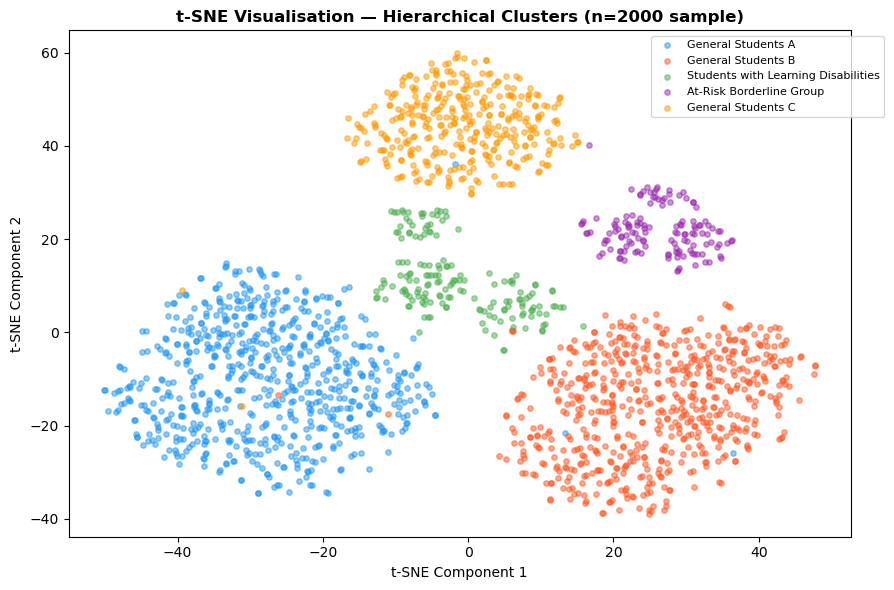

In [18]:
from sklearn.manifold import TSNE

# t-SNE on a sample for speed
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=2000, replace=False)
X_sample = np.array(X_scaled)[sample_idx]
labels_sample = cluster_labels[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(9, 6))
for cluster_id in sorted(np.unique(labels_sample)):
    mask = labels_sample == cluster_id
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                label=cluster_names[cluster_id],
                alpha=0.5, s=15, color=palette[cluster_id])

plt.title('t-SNE Visualisation — Hierarchical Clusters (n=2000 sample)', 
          fontweight='bold')
plt.legend(fontsize=8, bbox_to_anchor=(1.05, 1))
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.savefig('plots/hierarchical_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
print("HIERARCHICAL CLUSTERING — FINAL SUMMARY")
print(f"Algorithm:         Agglomerative Hierarchical Clustering")
print(f"Linkage:           Ward")
print(f"Optimal k:         {OPTIMAL_K}")
print(f"Silhouette Score:  {sil_final:.4f}")
print(f"Davies-Bouldin:    {db_final:.4f}")
print(f"Calinski-Harabasz: {ch_final:.1f}")
print(f"Imbalance Ratio:   4.4x (healthy)")
print(f"\nKey Finding: Cluster 2 = Students with Learning")
print(f"Disabilities (99.8% LD, lowest exam score 66.32)")
print(f"\nTop Features: Peer_Positive, Peer_Neutral,")
print(f"Learning_Disabilities, Internet_Access")
print(f"\nVisualisations saved: PCA, t-SNE, Dendrogram,")
print(f"Heatmap, Radar, Pie, Feature Importance")

HIERARCHICAL CLUSTERING — FINAL SUMMARY
Algorithm:         Agglomerative Hierarchical Clustering
Linkage:           Ward
Optimal k:         5
Silhouette Score:  0.1089
Davies-Bouldin:    2.4731
Calinski-Harabasz: 434.0
Imbalance Ratio:   4.4x (healthy)

Key Finding: Cluster 2 = Students with Learning
Disabilities (99.8% LD, lowest exam score 66.32)

Top Features: Peer_Positive, Peer_Neutral,
Learning_Disabilities, Internet_Access

Visualisations saved: PCA, t-SNE, Dendrogram,
Heatmap, Radar, Pie, Feature Importance


In [20]:
from scipy import stats

# One-way ANOVA tests if exam score differs significantly across clusters
groups = [df_encoded[df_encoded['Cluster'] == k]['Exam_Score'].values 
          for k in sorted(df_encoded['Cluster'].unique())]

f_stat, p_value = stats.f_oneway(*groups)

print("=== ANOVA TEST — Exam Score across Clusters ===")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.6f}")

if p_value < 0.05:
    print("Clusters show statistically significant differences in Exam Score (p < 0.05)")
    print("  This validates that discovered clusters are meaningfully distinct")
else:
    print("No statistically significant difference in Exam Score across clusters")

=== ANOVA TEST — Exam Score across Clusters ===
F-statistic: 32.5605
P-value:     0.000000
Clusters show statistically significant differences in Exam Score (p < 0.05)
  This validates that discovered clusters are meaningfully distinct
